In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("ecommerce_sales_data.csv")
print(df.head(10))

   Order Date Product Name     Category Region  Quantity  Sales   Profit
0  2024-12-31      Printer       Office  North         4   3640   348.93
1  2022-11-27        Mouse  Accessories   East         7   1197   106.53
2  2022-05-11       Tablet  Electronics  South         5   5865   502.73
3  2024-03-16        Mouse  Accessories  South         2    786   202.87
4  2022-09-10        Mouse  Accessories   West         1    509   103.28
5  2023-12-01       Camera  Electronics   West         1    524   106.35
6  2023-10-09   Headphones  Accessories  North         7   6167  1027.98
7  2022-01-14       Camera  Electronics  South         7   3059   873.50
8  2022-04-02   Smartwatch  Electronics   East         9   5526   595.28
9  2024-10-22      Printer       Office  South         8    672   186.37


In [3]:
print(df.shape)

(3500, 7)


In [4]:
print(df.columns)

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='str')


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   str    
 1   Product Name  3500 non-null   str    
 2   Category      3500 non-null   str    
 3   Region        3500 non-null   str    
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 191.5 KB
None


In [21]:
print(df.isnull().sum())

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64


In [28]:
print(df.duplicated().sum())

0


In [81]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
print(region_sales)

Region
West     2844450
East     2675110
South    2659548
North    2488773
Name: Sales, dtype: int64


In [80]:
highest_region = region_sales.idxmax()

highest_sales = region_sales.max()

print("Highest Sales Region:", highest_region)
print("Sales:", highest_sales)

Highest Sales Region: West
Sales: 2844450


In [9]:
lowest_region = region_sales.idxmin()

lowest_sales = region_sales.min()

print("Lowest Sales Region:", lowest_region)
print("Sales:", lowest_sales)

Lowest Sales Region: North
Sales: 2488773


In [19]:
west_sales = df[df["Region"] == "West"]

west_products = (
  west_sales.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(west_products)

Product Name
Monitor       333979
Smartphone    333706
Mouse         302826
Camera        302558
Smartwatch    275127
Tablet        274640
Laptop        272603
Printer       267849
Headphones    245579
Keyboard      235583
Name: Sales, dtype: int64


In [18]:
north_sales = df[df["Region"] == "North"]

north_products = (
    north_sales.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(north_products)

Product Name
Monitor       306624
Camera        281561
Mouse         263934
Keyboard      251399
Smartwatch    249044
Laptop        245796
Tablet        242750
Smartphone    225551
Printer       223430
Headphones    198684
Name: Sales, dtype: int64


In [16]:
sorted_sales = df.sort_values(
    by="Sales",
    ascending=False
)
sorted_sales

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
1127,2023-09-29,Keyboard,Accessories,South,9,10782,2730.14
32,2023-04-09,Laptop,Electronics,North,9,10773,1907.36
2573,2022-06-27,Laptop,Electronics,East,9,10728,1967.84
1489,2023-12-18,Monitor,Accessories,West,9,10665,1595.08
379,2022-05-09,Printer,Office,West,9,10656,961.30
...,...,...,...,...,...,...,...
1944,2024-12-18,Laptop,Electronics,East,1,58,11.25
2097,2024-07-12,Laptop,Electronics,North,1,58,10.79
844,2023-06-07,Keyboard,Accessories,West,1,56,9.16
3229,2022-08-02,Camera,Electronics,South,1,54,13.29


In [65]:
df["Month"] = df["Order Date"].dt.month
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Month
0,2024-12-31,Printer,Office,North,4,3640,348.93,12
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,11
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,5
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,3
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,9
...,...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16,2
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89,9
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02,4
3498,2022-01-18,Printer,Office,South,3,222,50.28,1


In [79]:
print(df.shape)

(3500, 8)


In [44]:
df["Sales"].sum()

np.int64(10667881)

In [45]:
df["Sales"].max()

np.int64(10782)

In [46]:
df["Sales"].min()

np.int64(51)

In [47]:
average_sales = np.mean(df["Sales"])

print("Average Sales:", average_sales)

Average Sales: 3047.966


In [48]:
average_profit = np.mean(df["Profit"])

print("Average Profit:", average_profit)

Average Profit: 527.0472028571428


In [49]:
median_sales = np.median(df["Sales"])

print("Median Sales:", median_sales)

Median Sales: 2350.5


In [50]:
total_sales = df["Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 10667881


In [51]:
total_profit = df["Profit"].sum()

print("Total Profit:", total_profit)

Total Profit: 1844665.21


In [52]:
total_quantity = df["Quantity"].sum()

print("Total Quantity:", total_quantity)

Total Quantity: 17261


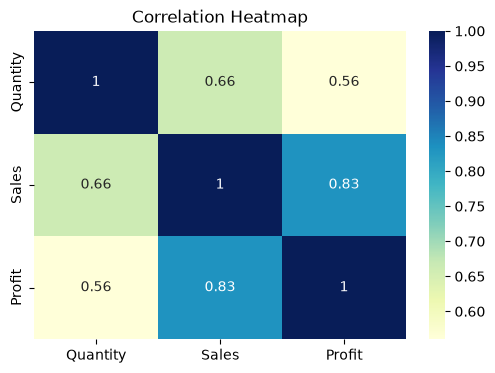

In [5]:
numeric_df = df[["Quantity", "Sales", "Profit"]]

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Correlation Heatmap")
plt.show()

In [54]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
print(top_products.head(10))

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: Sales, dtype: int64


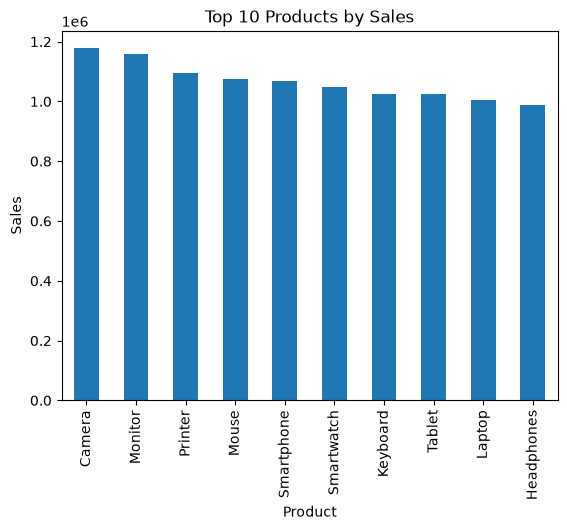

In [57]:
top_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

In [61]:
top_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)
print(top_profit_products.head(10))

Product Name
Camera        207630.99
Monitor       202028.17
Mouse         185763.69
Laptop        185756.81
Printer       185394.88
Smartphone    183296.97
Smartwatch    178995.81
Keyboard      175814.68
Headphones    172478.20
Tablet        167505.01
Name: Profit, dtype: float64


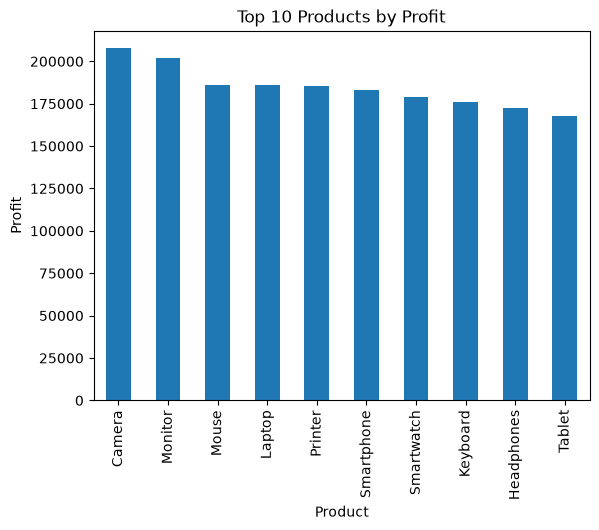

In [66]:
top_profit_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Profit")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.show()

In [67]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
print(category_sales)

Category
Electronics    5326074
Accessories    4247591
Office         1094216
Name: Sales, dtype: int64


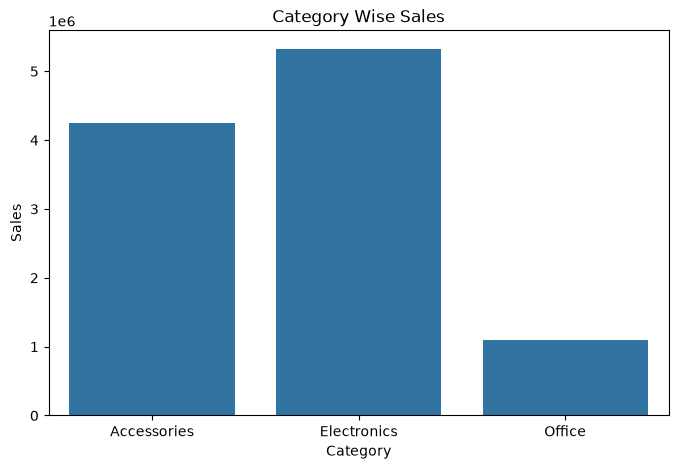

In [4]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x="Category",
    y="Sales"
)

plt.title("Category Wise Sales")
plt.show()

In [69]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
print(region_sales)

Region
West     2844450
East     2675110
South    2659548
North    2488773
Name: Sales, dtype: int64


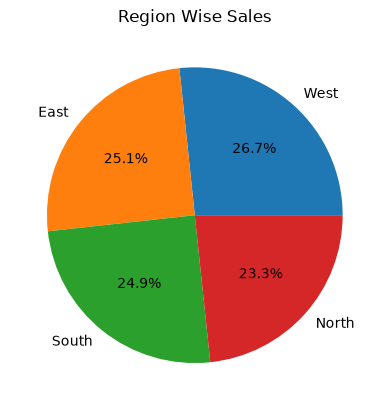

In [70]:
region_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Region Wise Sales")
plt.ylabel("")  
plt.show()

In [72]:
monthly_sales = (
    df.groupby(["Month"])["Sales"]
    .sum()
    .reset_index()
    .sort_values("Month")
)
print(monthly_sales)

    Month    Sales
0       1   967614
1       2   702414
2       3   939614
3       4   821876
4       5  1034687
5       6   839805
6       7   844940
7       8   924939
8       9   885546
9      10   892269
10     11   855075
11     12   959102


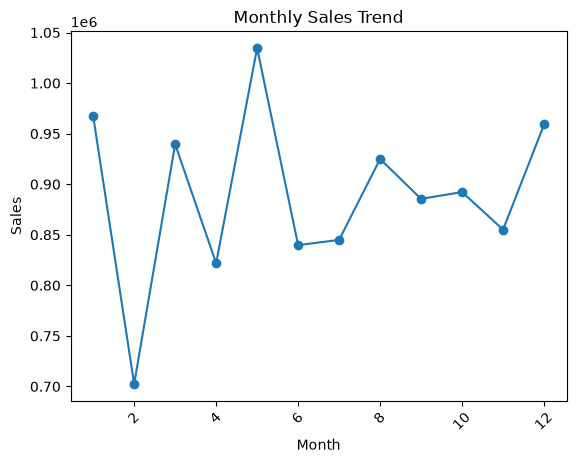

In [73]:
plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.show()

In [76]:
monthly_profit = (
    df.groupby(["Month"])["Profit"]
    .sum()
    .reset_index()
    .sort_values("Month")
)
print(monthly_profit)

    Month     Profit
0       1  177280.29
1       2  118958.72
2       3  162136.63
3       4  145620.96
4       5  173293.15
5       6  143198.53
6       7  149244.11
7       8  152959.89
8       9  150265.04
9      10  153027.97
10     11  144837.79
11     12  173842.13


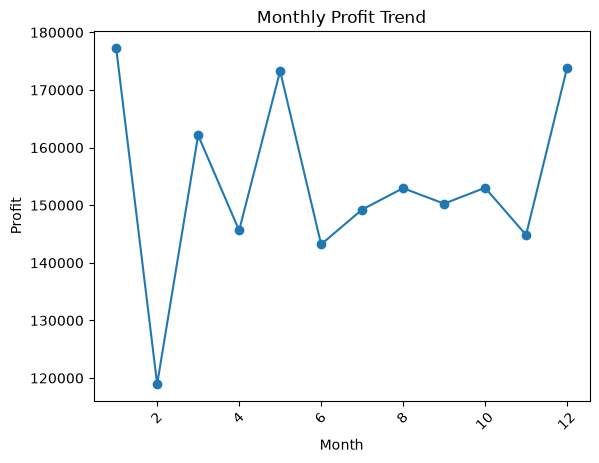

In [78]:
plt.plot(
    monthly_profit["Month"],
    monthly_profit["Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.show()